In [2]:
#import thinkplot
#import thinkstats2
import pandas as pd
import numpy as np
import math
import scipy.stats as ss
# import thinkplot
# import thinkstats2

##Seaborn for fancy plots.
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (15,5)

<h1>Assignment 2: Life Expectancy and You!</h1>

<b>Instructions:</b>
<ul>
<li>Use the worksheet below to act as a guide to exploring and examining the data in the dataset.
<li>Try to make things easy to read. Look at the formatting stuff above.
<li>As long as you do what is asked, you can do things in many different ways. You may need to do a little searching.
</ul>

### Please Use Formatting to Make it Clear What I Should be Looking at! Please!!! I Beg You!!!

In [3]:
#Load data and do some cleanup before starting
#Please don't change this stuff.
dfLE = pd.read_csv("led.csv")
dfLE.rename(columns={"Status":"isDeveloped", }, inplace=True)
dfLE["isDeveloped"].replace(('Developed', 'Developing'), (1, 0), inplace=True)
dfLE = dfLE.drop(columns={"Year", "Incomecompositionofresources", "thinness5-9years", "HIV/AIDS", "percentageexpenditure", "Totalexpenditure", "thinness1-19years"})
dfLE = dfLE.groupby("Country", as_index=False).mean()
dfLE.head()


C:\Users\Josen\AppData\Local\Temp\ipykernel_4580\519325125.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfLE["isDeveloped"].replace(('Developed', 'Developing'), (1, 0), inplace=True)
C:\Users\Josen\AppData\Local\Temp\ipykernel_4580\519325125.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
 

,Country,isDeveloped,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,HepatitisB,Measles,BMI,under-fivedeaths,Polio,Diphtheria,GDP,Population,Schooling
0,Afghanistan,0.0,58.19375,269.0625,78.2500,0.014375,64.562500,2362.2500,15.51875,107.5625,48.3750,52.3125,4.136734e+09,9.972260e+06,8.21250
1,Albania,0.0,75.15625,45.0625,0.6875,4.848750,98.000000,53.3750,49.06875,0.9375,98.1250,98.0625,1.166938e+09,6.969116e+05,12.13750
2,Algeria,0.0,73.61875,108.1875,20.3125,0.406667,78.000000,1943.8750,48.74375,23.5000,91.7500,91.8750,7.345597e+10,2.164983e+07,12.71250
3,Angola,0.0,49.01875,328.5625,83.7500,5.740667,70.222222,3561.3125,18.01875,132.6250,46.1250,47.6875,2.177835e+10,1.014710e+07,8.04375
4,AntiguaandBarbuda,0.0,75.05625,127.5000,0.0000,7.949333,98.266667,0.0000,38.42500,0.0000,96.9375,98.3125,0.000000e+00,NaN,8.84375


<h2>Part 1: Add a column for GDP per Capita (5pts)</h2>

Show print the labels along with just that column. Print 10 random rows of that data.

Note: you'll have to look at the units to ensure you get it right.

In [4]:
dfLE["GDPperCapita"] = dfLE["GDP"] / dfLE["Population"]
dfLE.head()

,Country,isDeveloped,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,HepatitisB,Measles,BMI,under-fivedeaths,Polio,Diphtheria,GDP,Population,Schooling,GDPperCapita
0,Afghanistan,0.0,58.19375,269.0625,78.2500,0.014375,64.562500,2362.2500,15.51875,107.5625,48.3750,52.3125,4.136734e+09,9.972260e+06,8.21250,414.824126
1,Albania,0.0,75.15625,45.0625,0.6875,4.848750,98.000000,53.3750,49.06875,0.9375,98.1250,98.0625,1.166938e+09,6.969116e+05,12.13750,1674.441147
2,Algeria,0.0,73.61875,108.1875,20.3125,0.406667,78.000000,1943.8750,48.74375,23.5000,91.7500,91.8750,7.345597e+10,2.164983e+07,12.71250,3392.912329
3,Angola,0.0,49.01875,328.5625,83.7500,5.740667,70.222222,3561.3125,18.01875,132.6250,46.1250,47.6875,2.177835e+10,1.014710e+07,8.04375,2146.263722
4,AntiguaandBarbuda,0.0,75.05625,127.5000,0.0000,7.949333,98.266667,0.0000,38.42500,0.0000,96.9375,98.3125,0.000000e+00,NaN,8.84375,NaN


In [5]:
dfLE['GDPperCapita']

0       414.824126
1      1674.441147
2      3392.912329
3      2146.263722
4              NaN
          ...     
186            NaN
187            NaN
188            NaN
189     787.400504
190     420.419083
Name: GDPperCapita, Length: 191, dtype: float64

In [6]:
dfLE.sample(10)

,Country,isDeveloped,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,HepatitisB,Measles,BMI,under-fivedeaths,Polio,Diphtheria,GDP,Population,Schooling,GDPperCapita
164,Sweden,1.0,82.51875,59.1875,0.0000,6.926667,59.200000,18.9375,56.25000,0.0000,98.3125,98.3125,1.784113e+11,5.514868e+06,15.86875,32350.966244
65,Ghana,0.0,60.86250,180.0625,40.3125,1.268667,67.500000,3419.7500,21.72500,59.8125,78.9375,73.8750,1.270264e+10,1.153478e+07,9.51250,1101.246999
165,Switzerland,1.0,82.33125,55.7500,0.0000,10.338000,NaN,397.5000,51.43750,0.0000,95.3750,94.5625,3.548716e+11,5.913242e+06,15.39375,60013.030006
47,Denmark,1.0,79.25625,66.0625,0.0000,10.708000,NaN,15.7500,55.82500,0.0000,88.0000,88.0000,1.293716e+11,4.260081e+06,17.19375,30368.338530
129,PapuaNewGuinea,0.0,61.68125,266.5625,10.6250,0.580667,57.000000,2349.8750,40.78750,13.7500,62.5625,68.3750,3.610450e+09,4.813446e+06,8.54375,750.075931
91,LaoPeople'sDemocraticRepublic,0.0,62.38125,197.1875,10.6250,3.505333,60.307692,552.7500,14.36250,14.7500,58.8125,61.5000,0.000000e+00,NaN,9.23125,NaN
128,Panama,0.0,76.48750,115.8750,1.1250,6.212000,78.666667,0.2500,49.31250,1.6875,84.6875,80.0000,1.385038e+10,1.955022e+06,12.77500,7084.512422
149,Serbia,0.0,73.95625,130.4375,1.0000,8.682667,90.750000,73.8125,52.13750,1.0625,94.6250,93.3125,1.358398e+10,3.608280e+06,13.53125,3764.668739
152,Singapore,1.0,81.47500,62.0000,0.0000,1.762500,95.875000,85.7500,25.90625,0.0000,96.1250,96.1875,0.000000e+00,NaN,13.98125,NaN
67,Grenada,0.0,73.29375,153.7500,0.0000,8.843333,95.466667,0.0000,40.21250,0.0000,95.1250,95.6250,0.000000e+00,NaN,15.20625,NaN


### Part 2: Print a visualization of each distribution. Both regular (density) and cumulative. (15pts)

Print each distribution is some type of visualization, also print the cumulative distribution.
<ul>
<li>5 points are for using some visualization that is effective.
<li>5 points for formatting things in a nice layout. Hint: for whatever chart you use, look into some formatting options. Think of what to try to Google for an example for printing multiple charts, a grid of charts, etc... and try to adapt one to yours. There is also a way to do it using some thinkstats/thinkplot stuff.
<li><b>5 points are for doing it in an efficient way - just listing off each column is lots of typing... Remember, the #1 trait of programmers is laziness with respect to repetitive tasks. If we are doing the same thing over and over with tiny changes, try to think of a condensed way to do this...</b>
</ul>

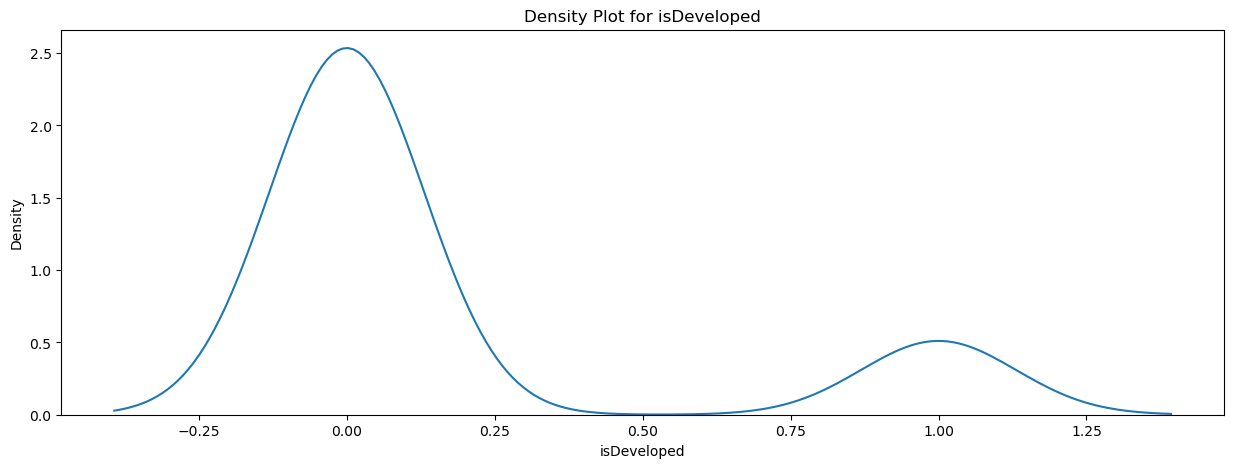

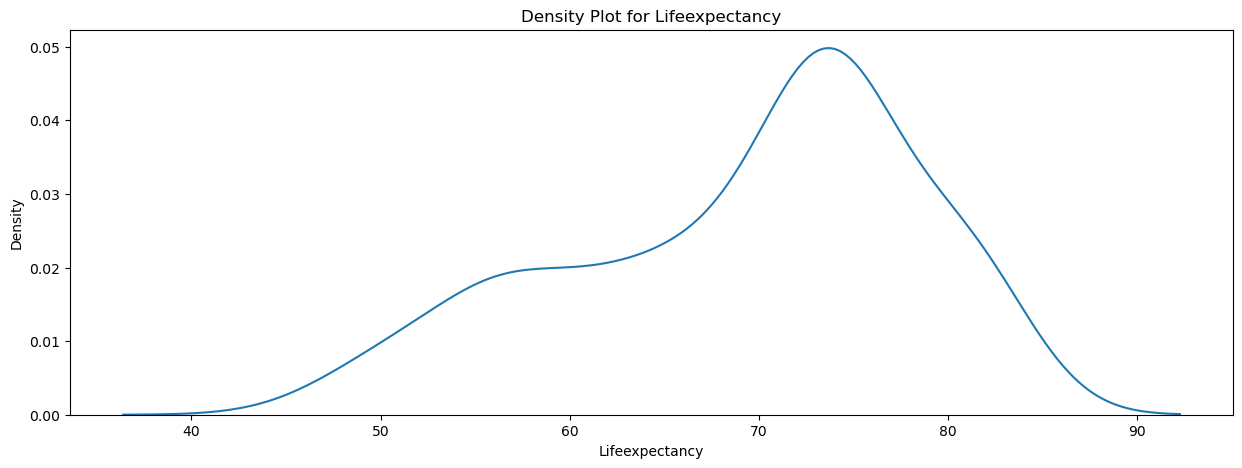

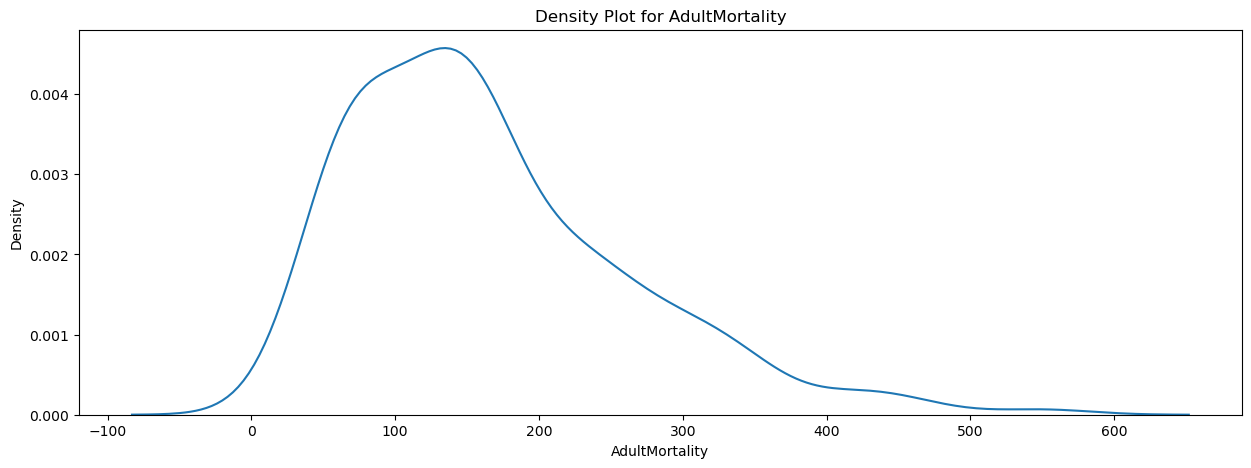

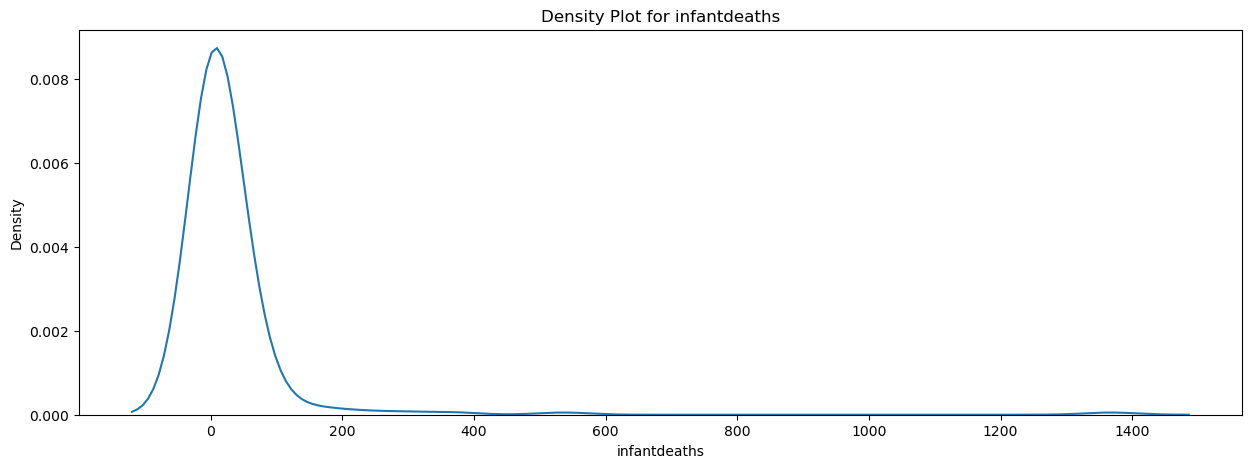

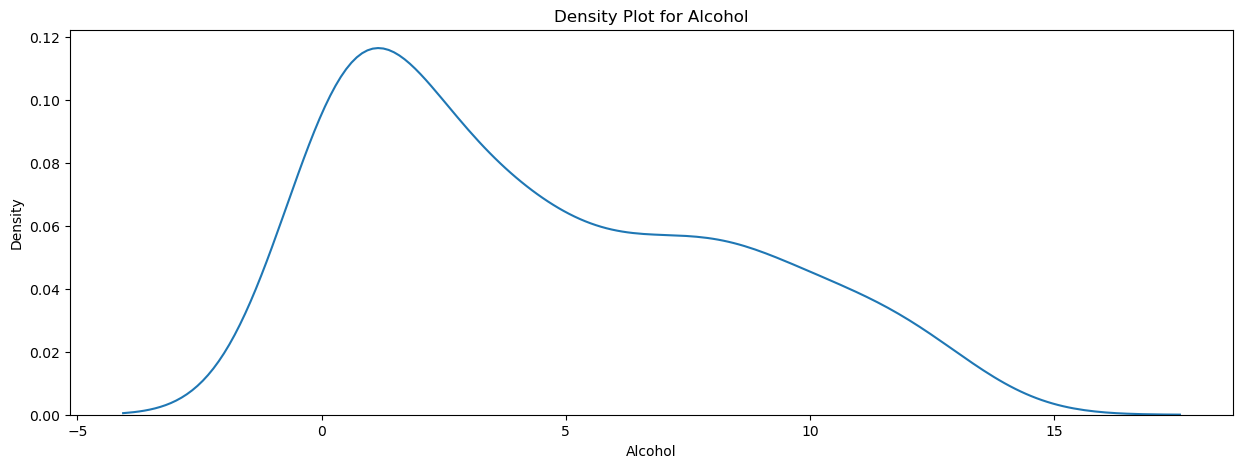

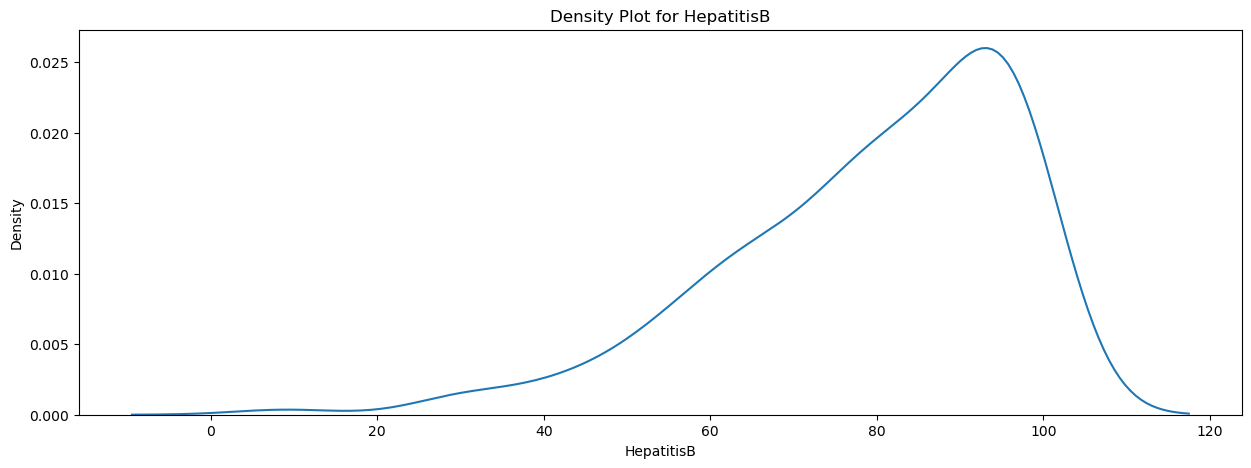

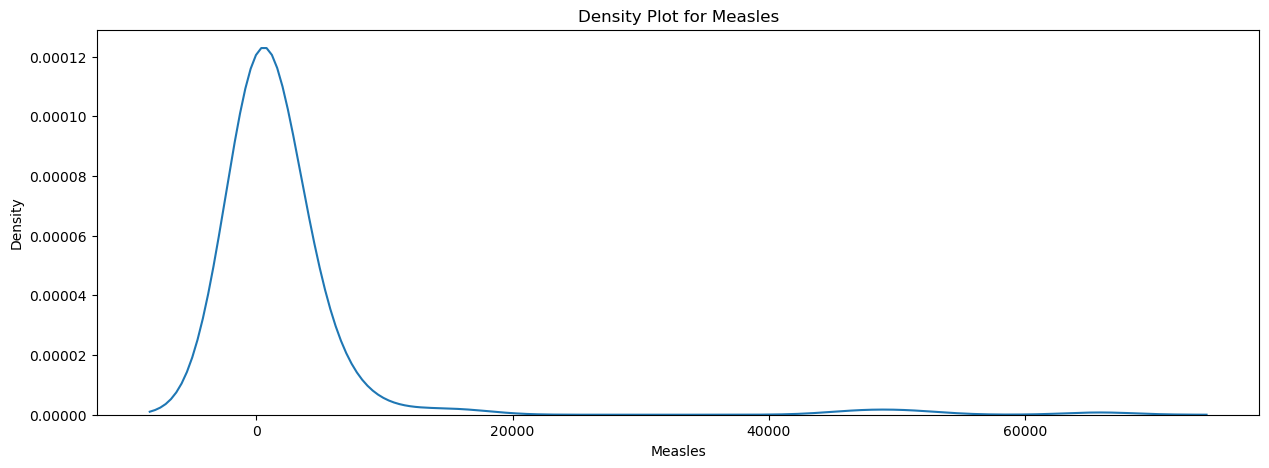

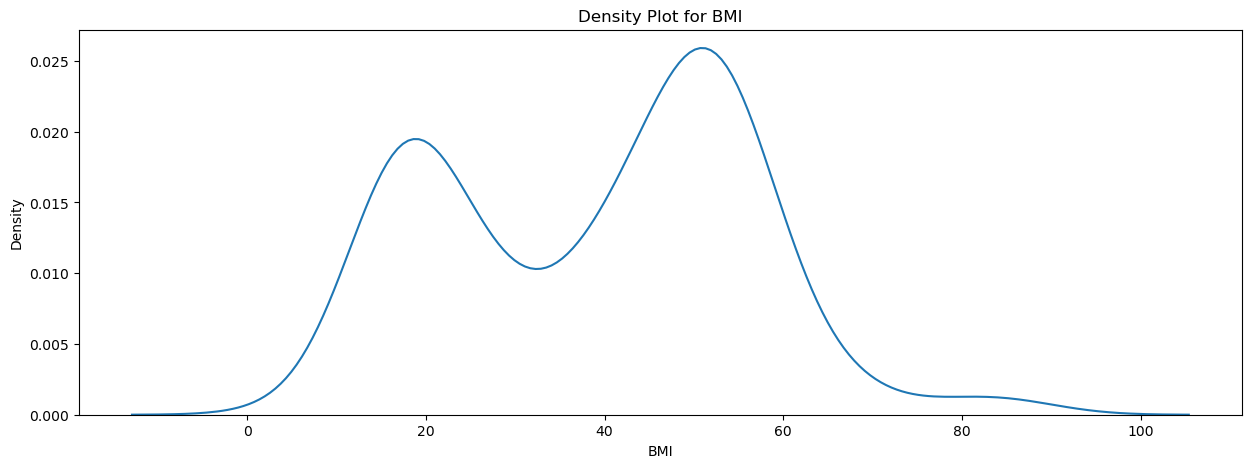

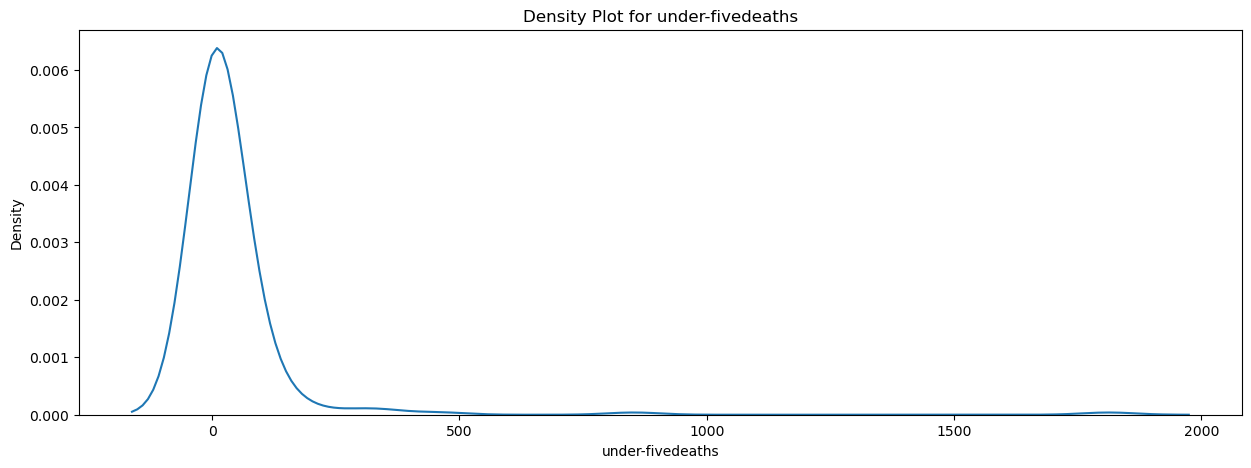

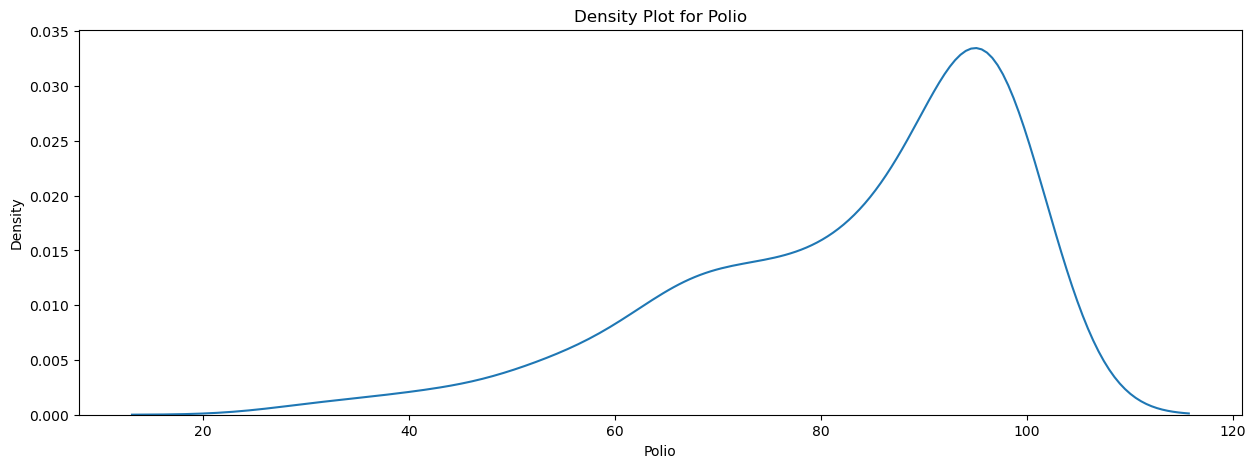

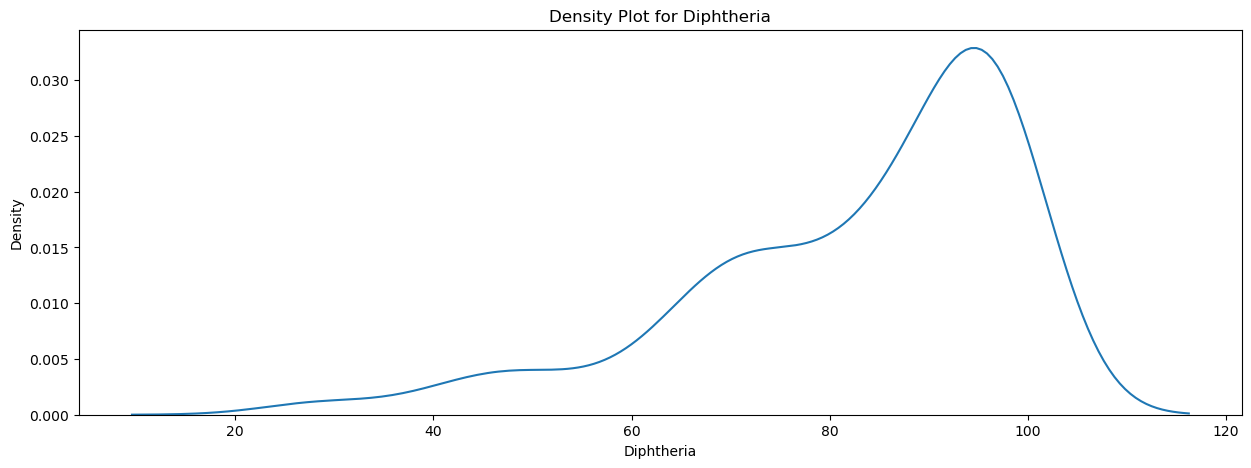

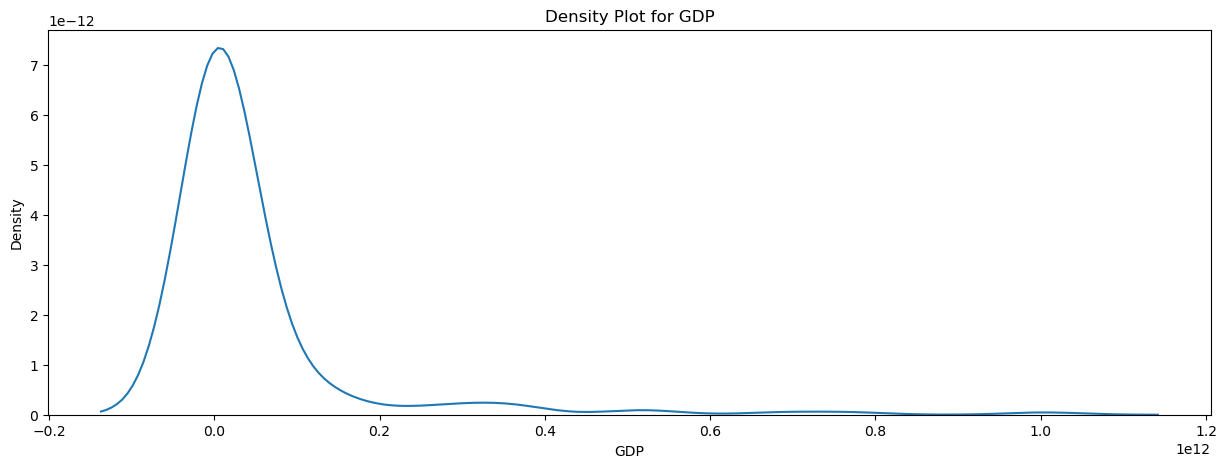

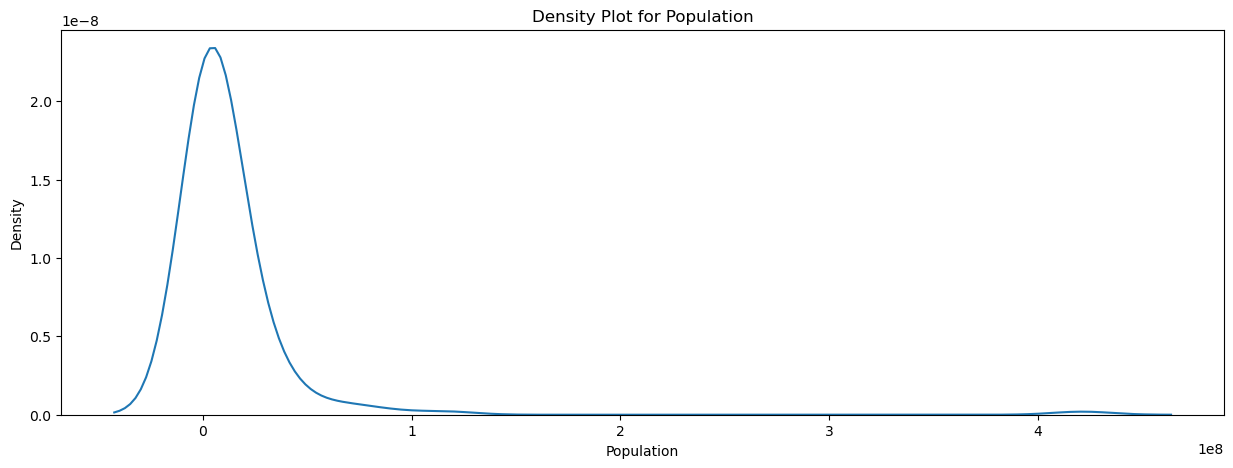

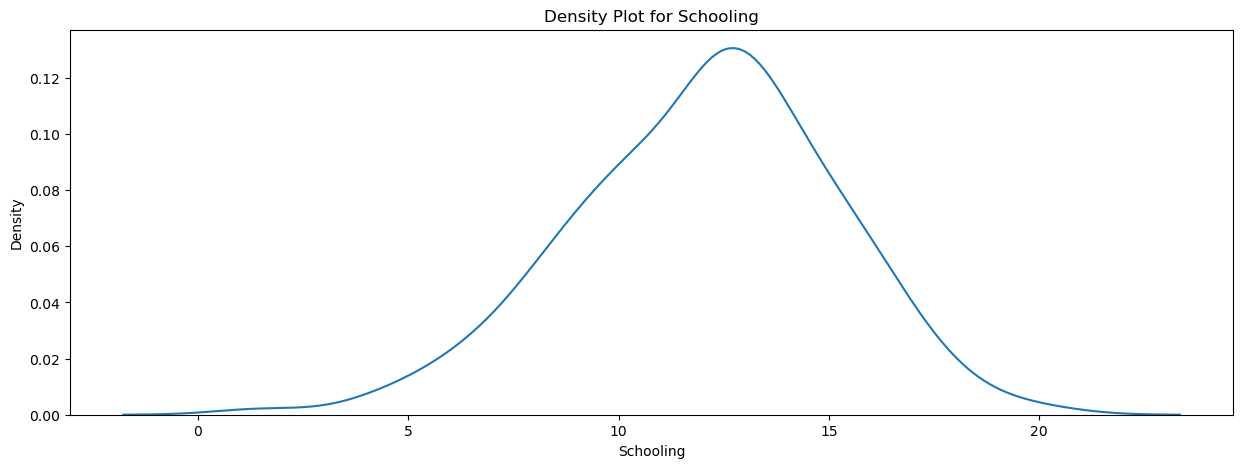

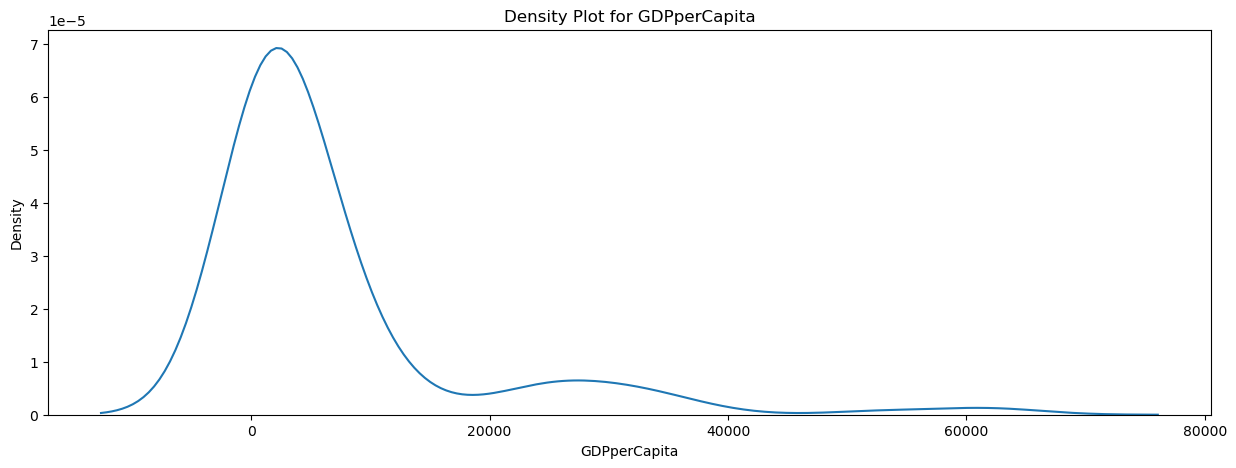

In [7]:
for i in dfLE.select_dtypes(include = 'number').columns:
    plt.figure()
    sns.kdeplot(dfLE[i], cumulative=False)
    plt.title(f'Density Plot for {i}')

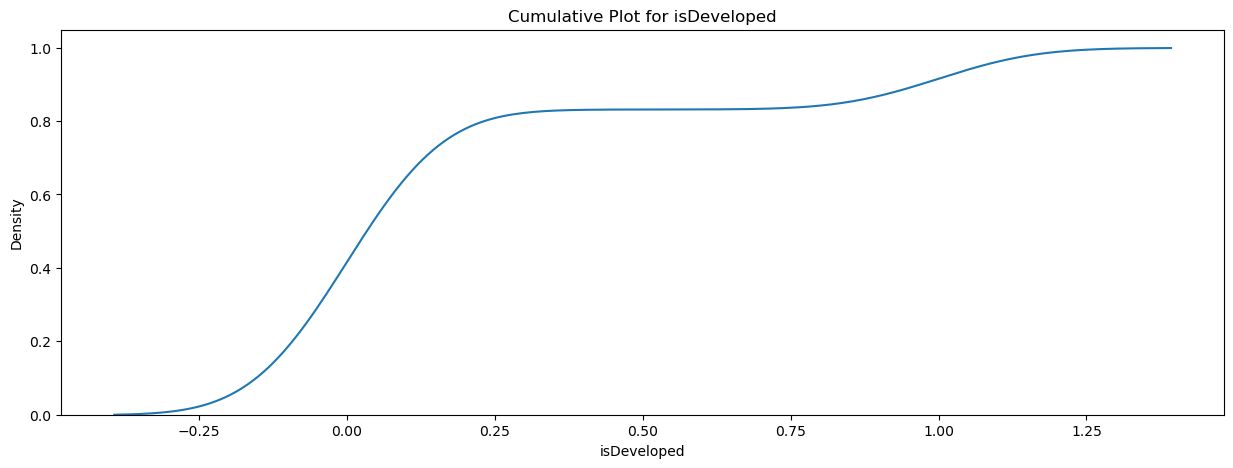

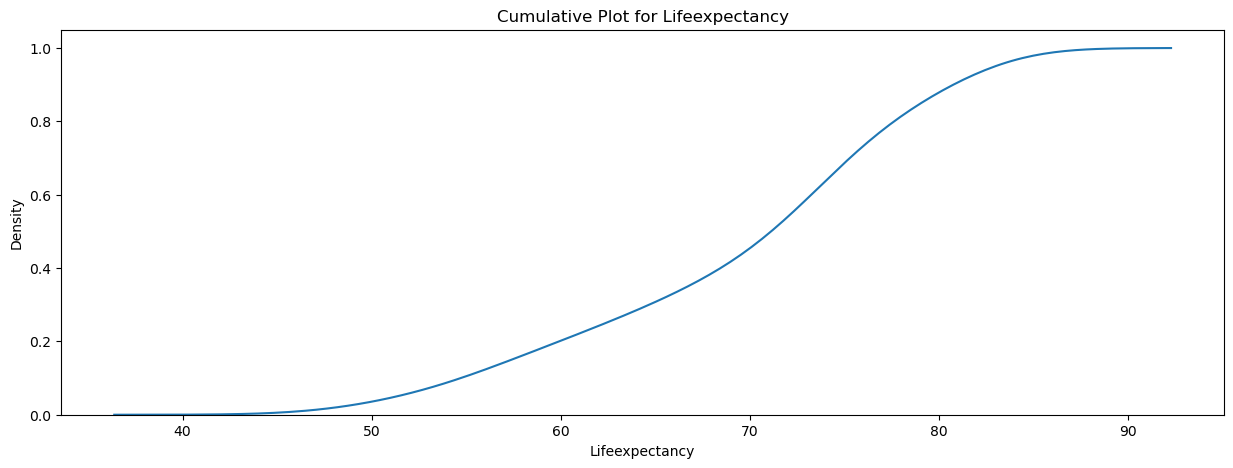

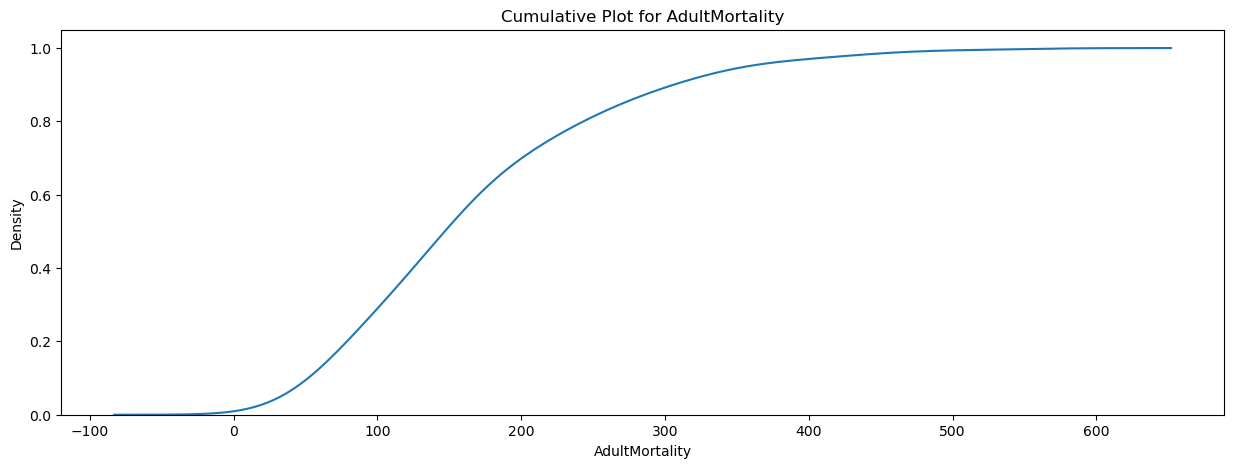

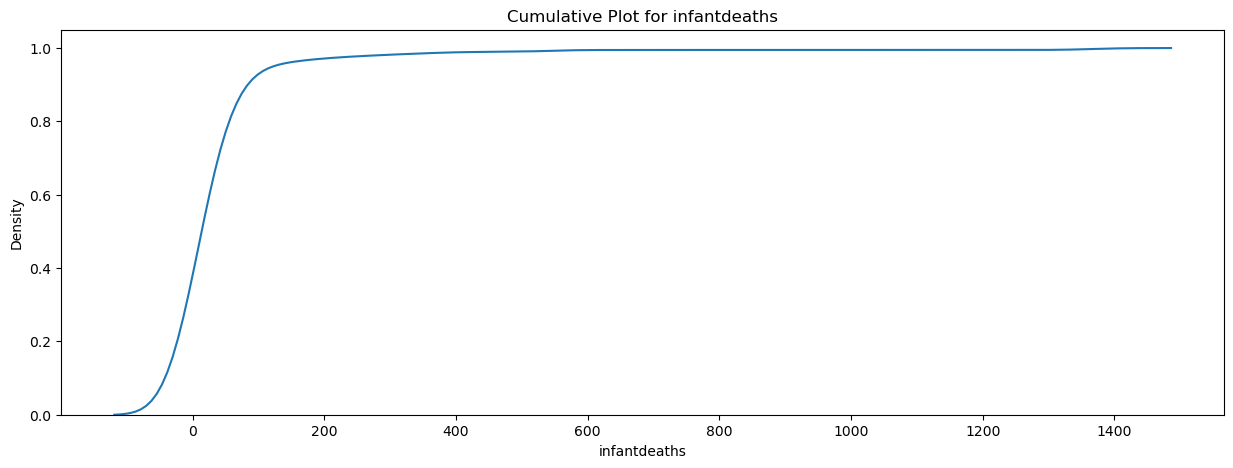

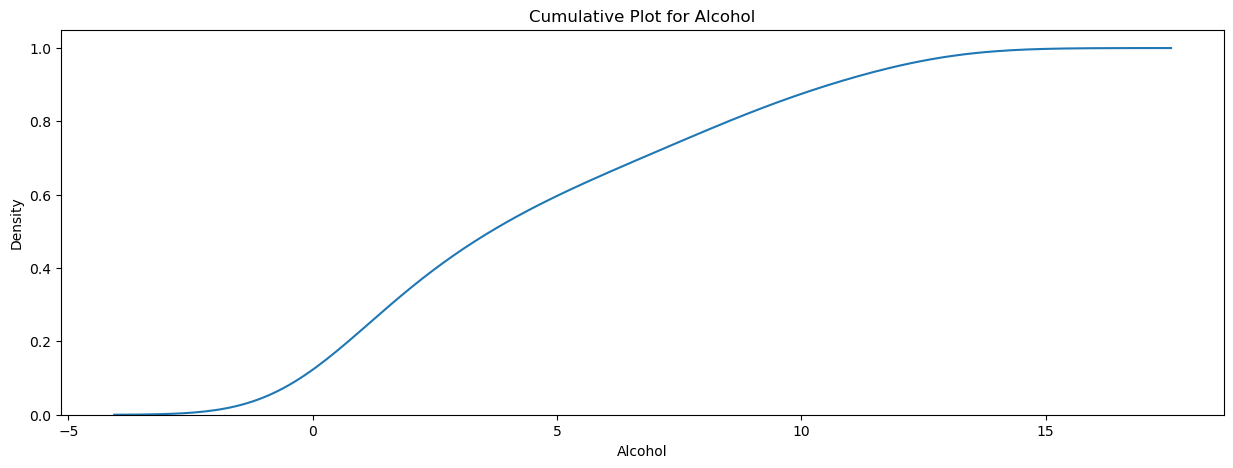

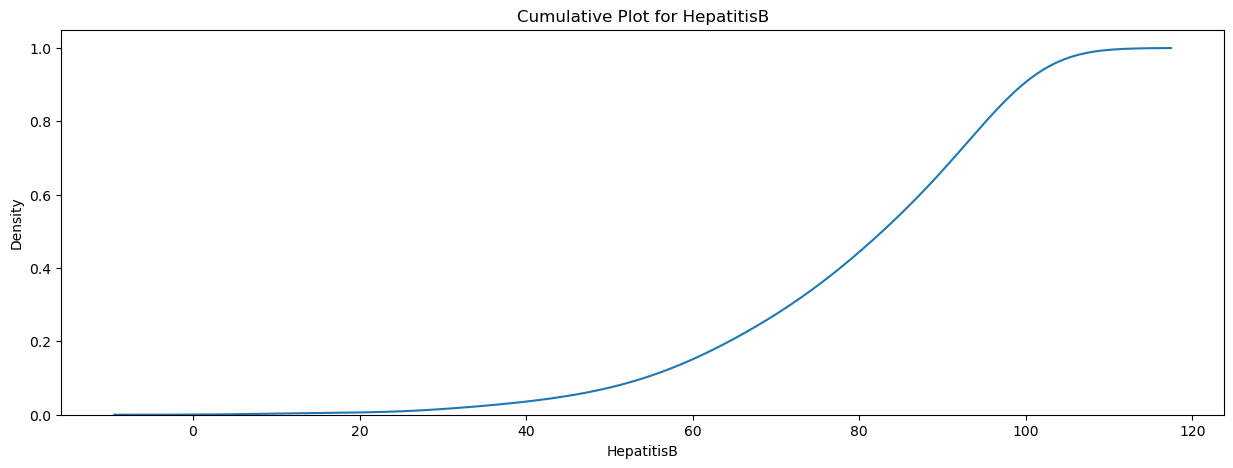

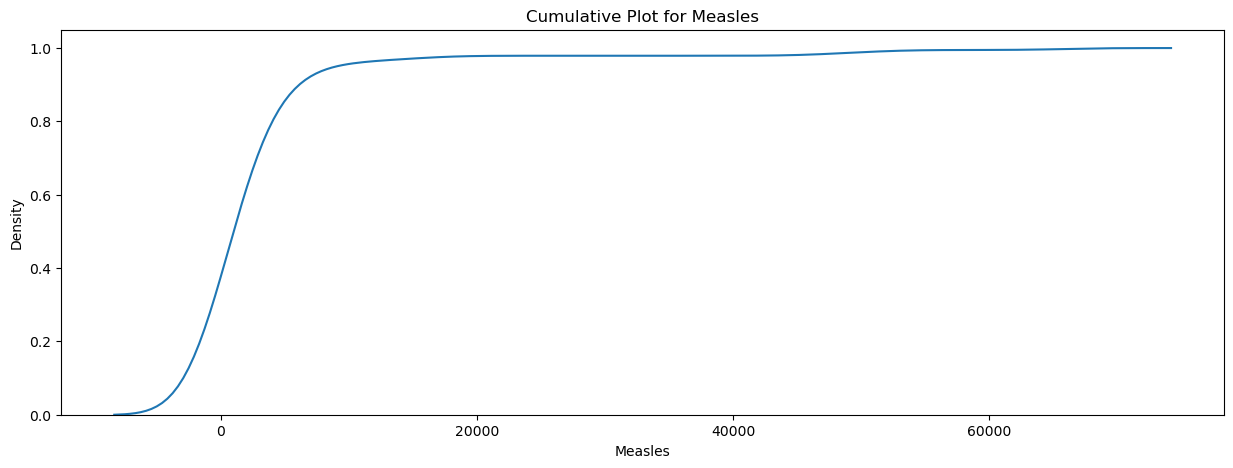

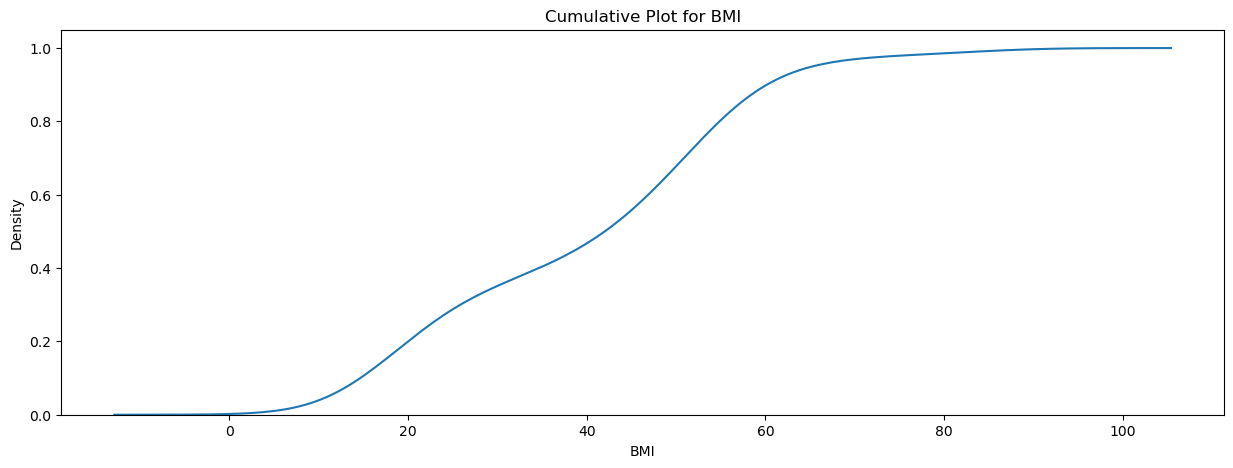

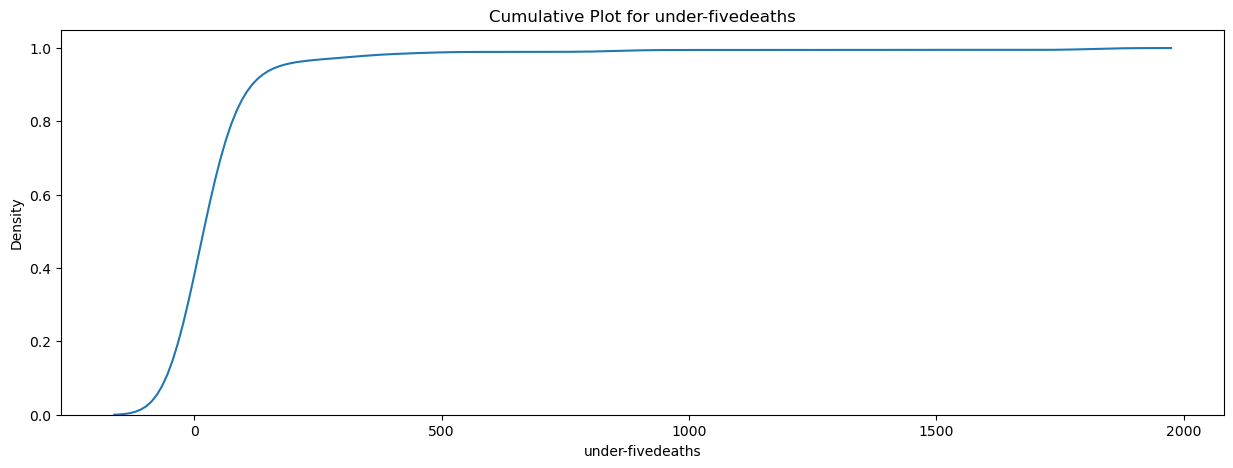

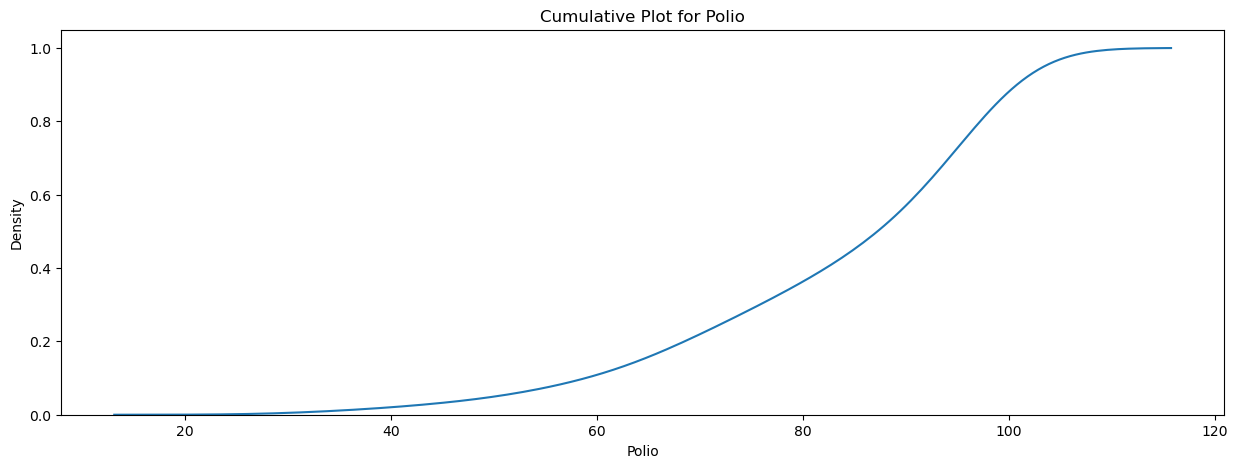

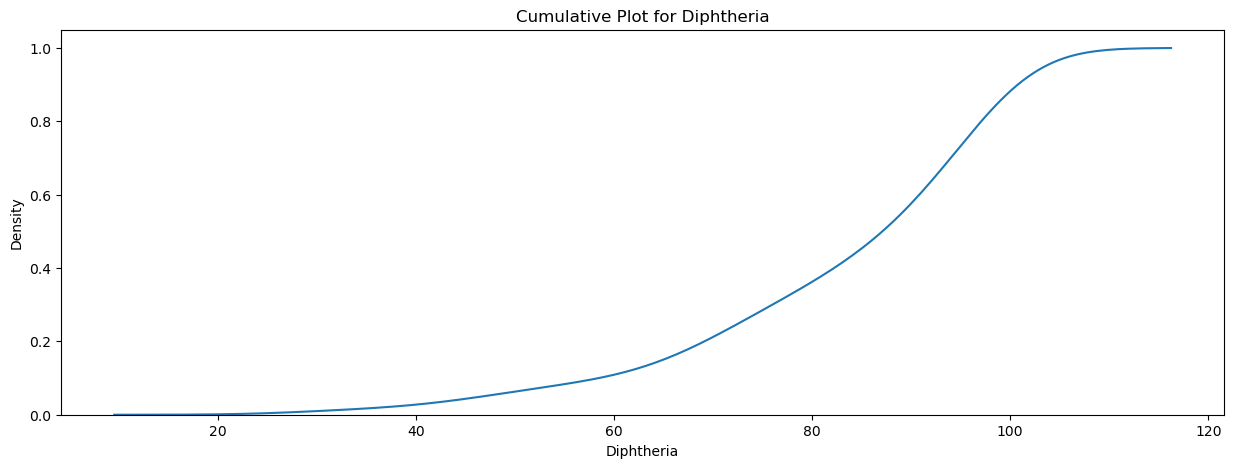

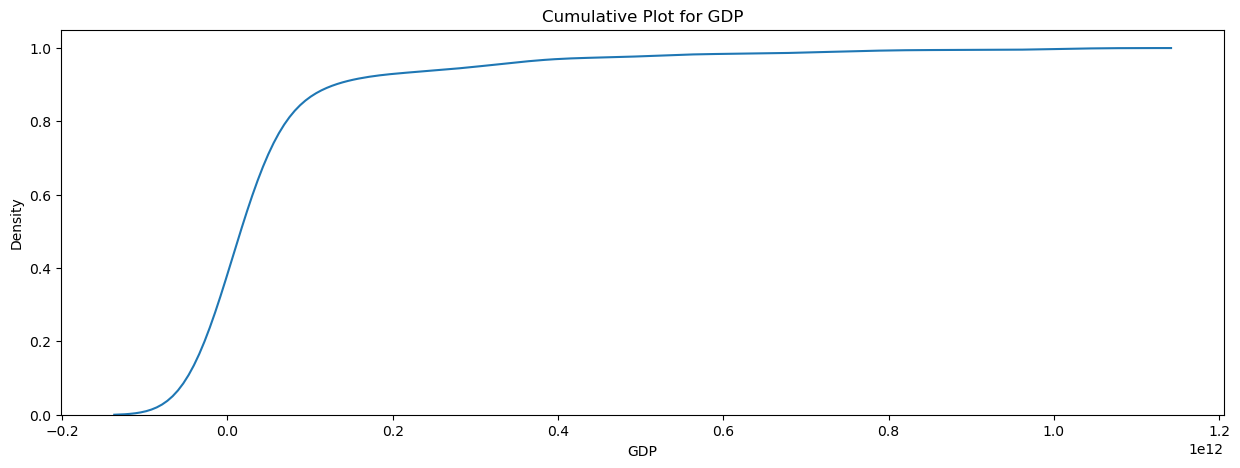

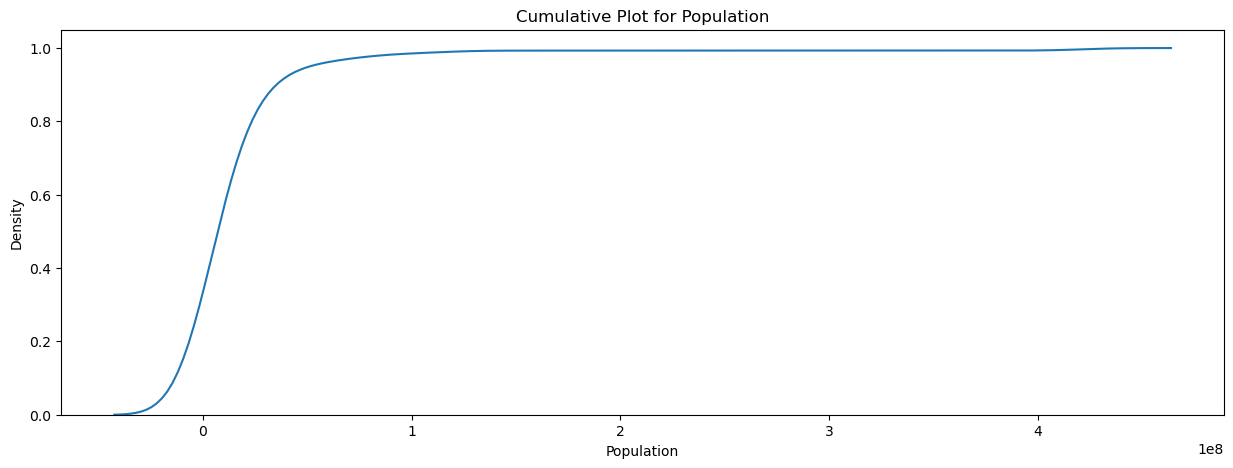

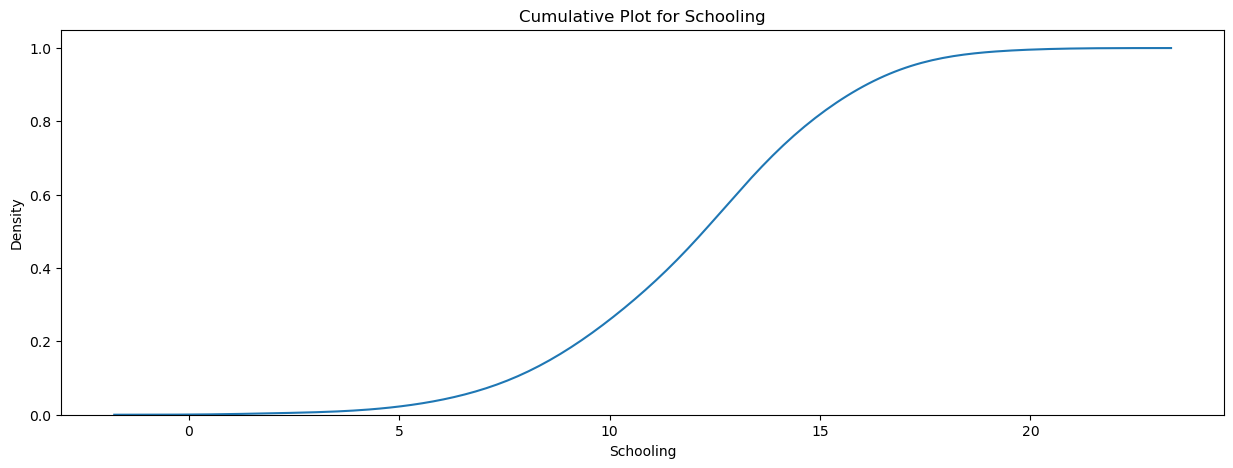

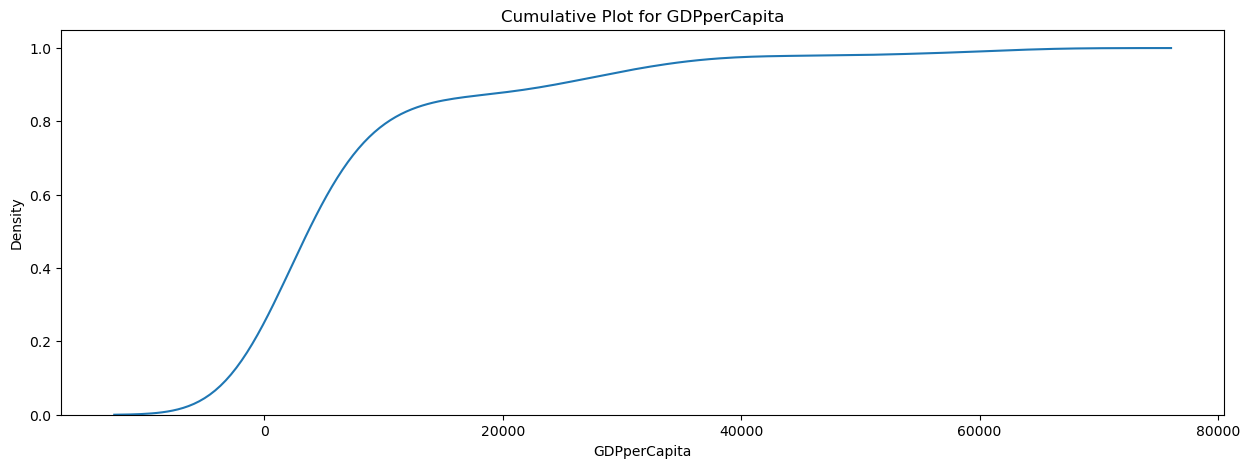

In [8]:
for i in dfLE.select_dtypes(include = 'number').columns:
    plt.figure()
    sns.kdeplot(dfLE[i], cumulative=True)
    plt.title(f'Cumulative Plot for {i}')

### Create an analytical distribution for SCHOOLING, and use it for a couple of things. (20pts)

<ul>
<li>5 points are for choosing an appropriate distribution. Please state it clearly somewhere.
<li>10 points are for creating and visualizing the distribution. Do it <b>without</b> using a fit() method. Plot the emperical data on the same graph as the analytical distribution.
<li>5 points are for using the distribution to predict the percentage of that have a schooling level within 1 year of Canada.
</ul>

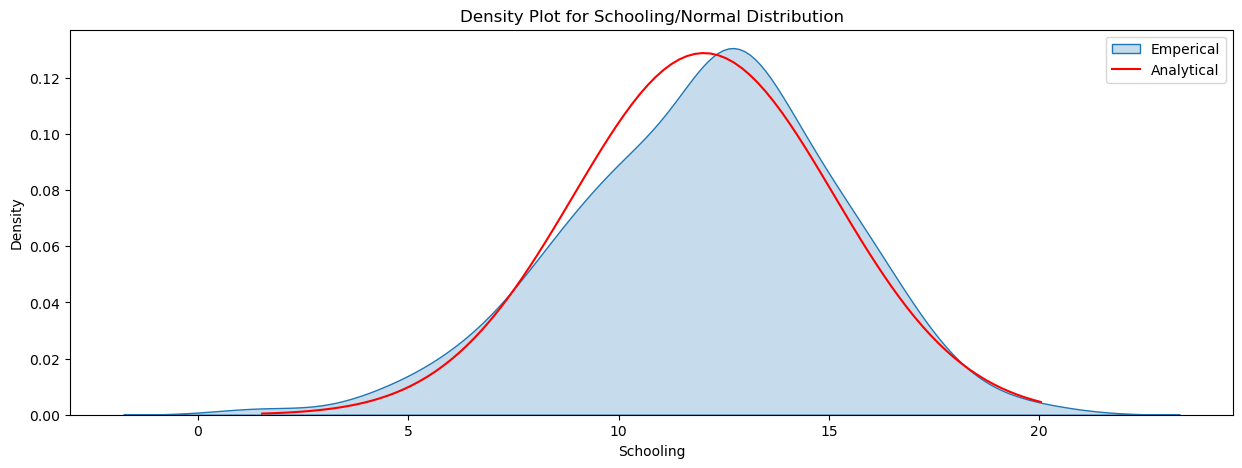

In [9]:
X = np.linspace(min(dfLE["Schooling"]), max(dfLE["Schooling"]), 100)
y_norm = ss.norm.pdf(X, loc = np.mean(dfLE['Schooling']), scale =  np.std(dfLE['Schooling']))
plt.figure()
sns.kdeplot(dfLE['Schooling'], fill = True, label = 'Emperical')
plt.title('Density Plot for Schooling/Normal Distribution')
plt.plot(X, y_norm, color = 'red', label = 'Analytical')
plt.legend()



### Part 3: Create another analytical distribution for GDP per Capita (20pts)

<ul>
<li>5 points are for choosing an appropriate distribution. Please state it clearly somewhere.
<li>10 points are for creating and visualizing it alongside the emperical. You have free reign on how.
<li>5 points are for using the analytical distribution to evaluate the quality of your GDP per capita metric - does it appear accurate? Why or why not?
<li>If you've judged GDP per cap to be unreliable, drop it.
</ul>

### 3a and b.

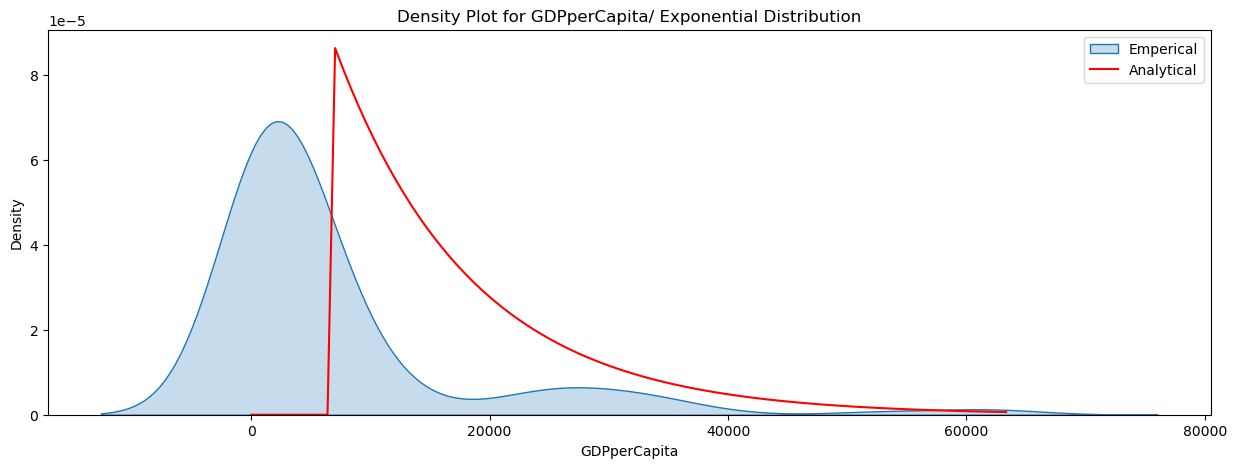

In [10]:
X = np.linspace(min(dfLE["Schooling"]), max(dfLE['GDPperCapita']), 100)
y_norm = ss.expon.pdf(X, loc = np.mean(dfLE['GDPperCapita']), scale =  np.std(dfLE['GDPperCapita']))
plt.figure()
sns.kdeplot(dfLE['GDPperCapita'], fill = True, label = 'Emperical')
plt.title('Density Plot for GDPperCapita/ Exponential Distribution')
plt.plot(X, y_norm, color = 'red', label = 'Analytical')
plt.legend()


### 3c. It does not appear accurate because the emperical distribution does't overlap the analytical distribution

### 3d.


In [11]:
dfLE.drop(columns = 'GDPperCapita', inplace = True)

### Part 4: Visually identify correlations. Separate developed and not developed countries is some way. (15pts)

<ul>
<li>5 points are for effectively and clearly showing the visualizations used to evaluate correlations.
<li>10 points are for, in the process of visualizing, remove outliers that confound correlations. List outlier "filters" you used and justify why - was the data an error, a real value that is just way out of line, or somethingn else? Remember, you're trying to find things that have correlations with each other. Looking at a correlation between home size and income may not benefit from Jeff Bezos being included. It may be helpful to look at the results and revise.
</ul>

### 4a.

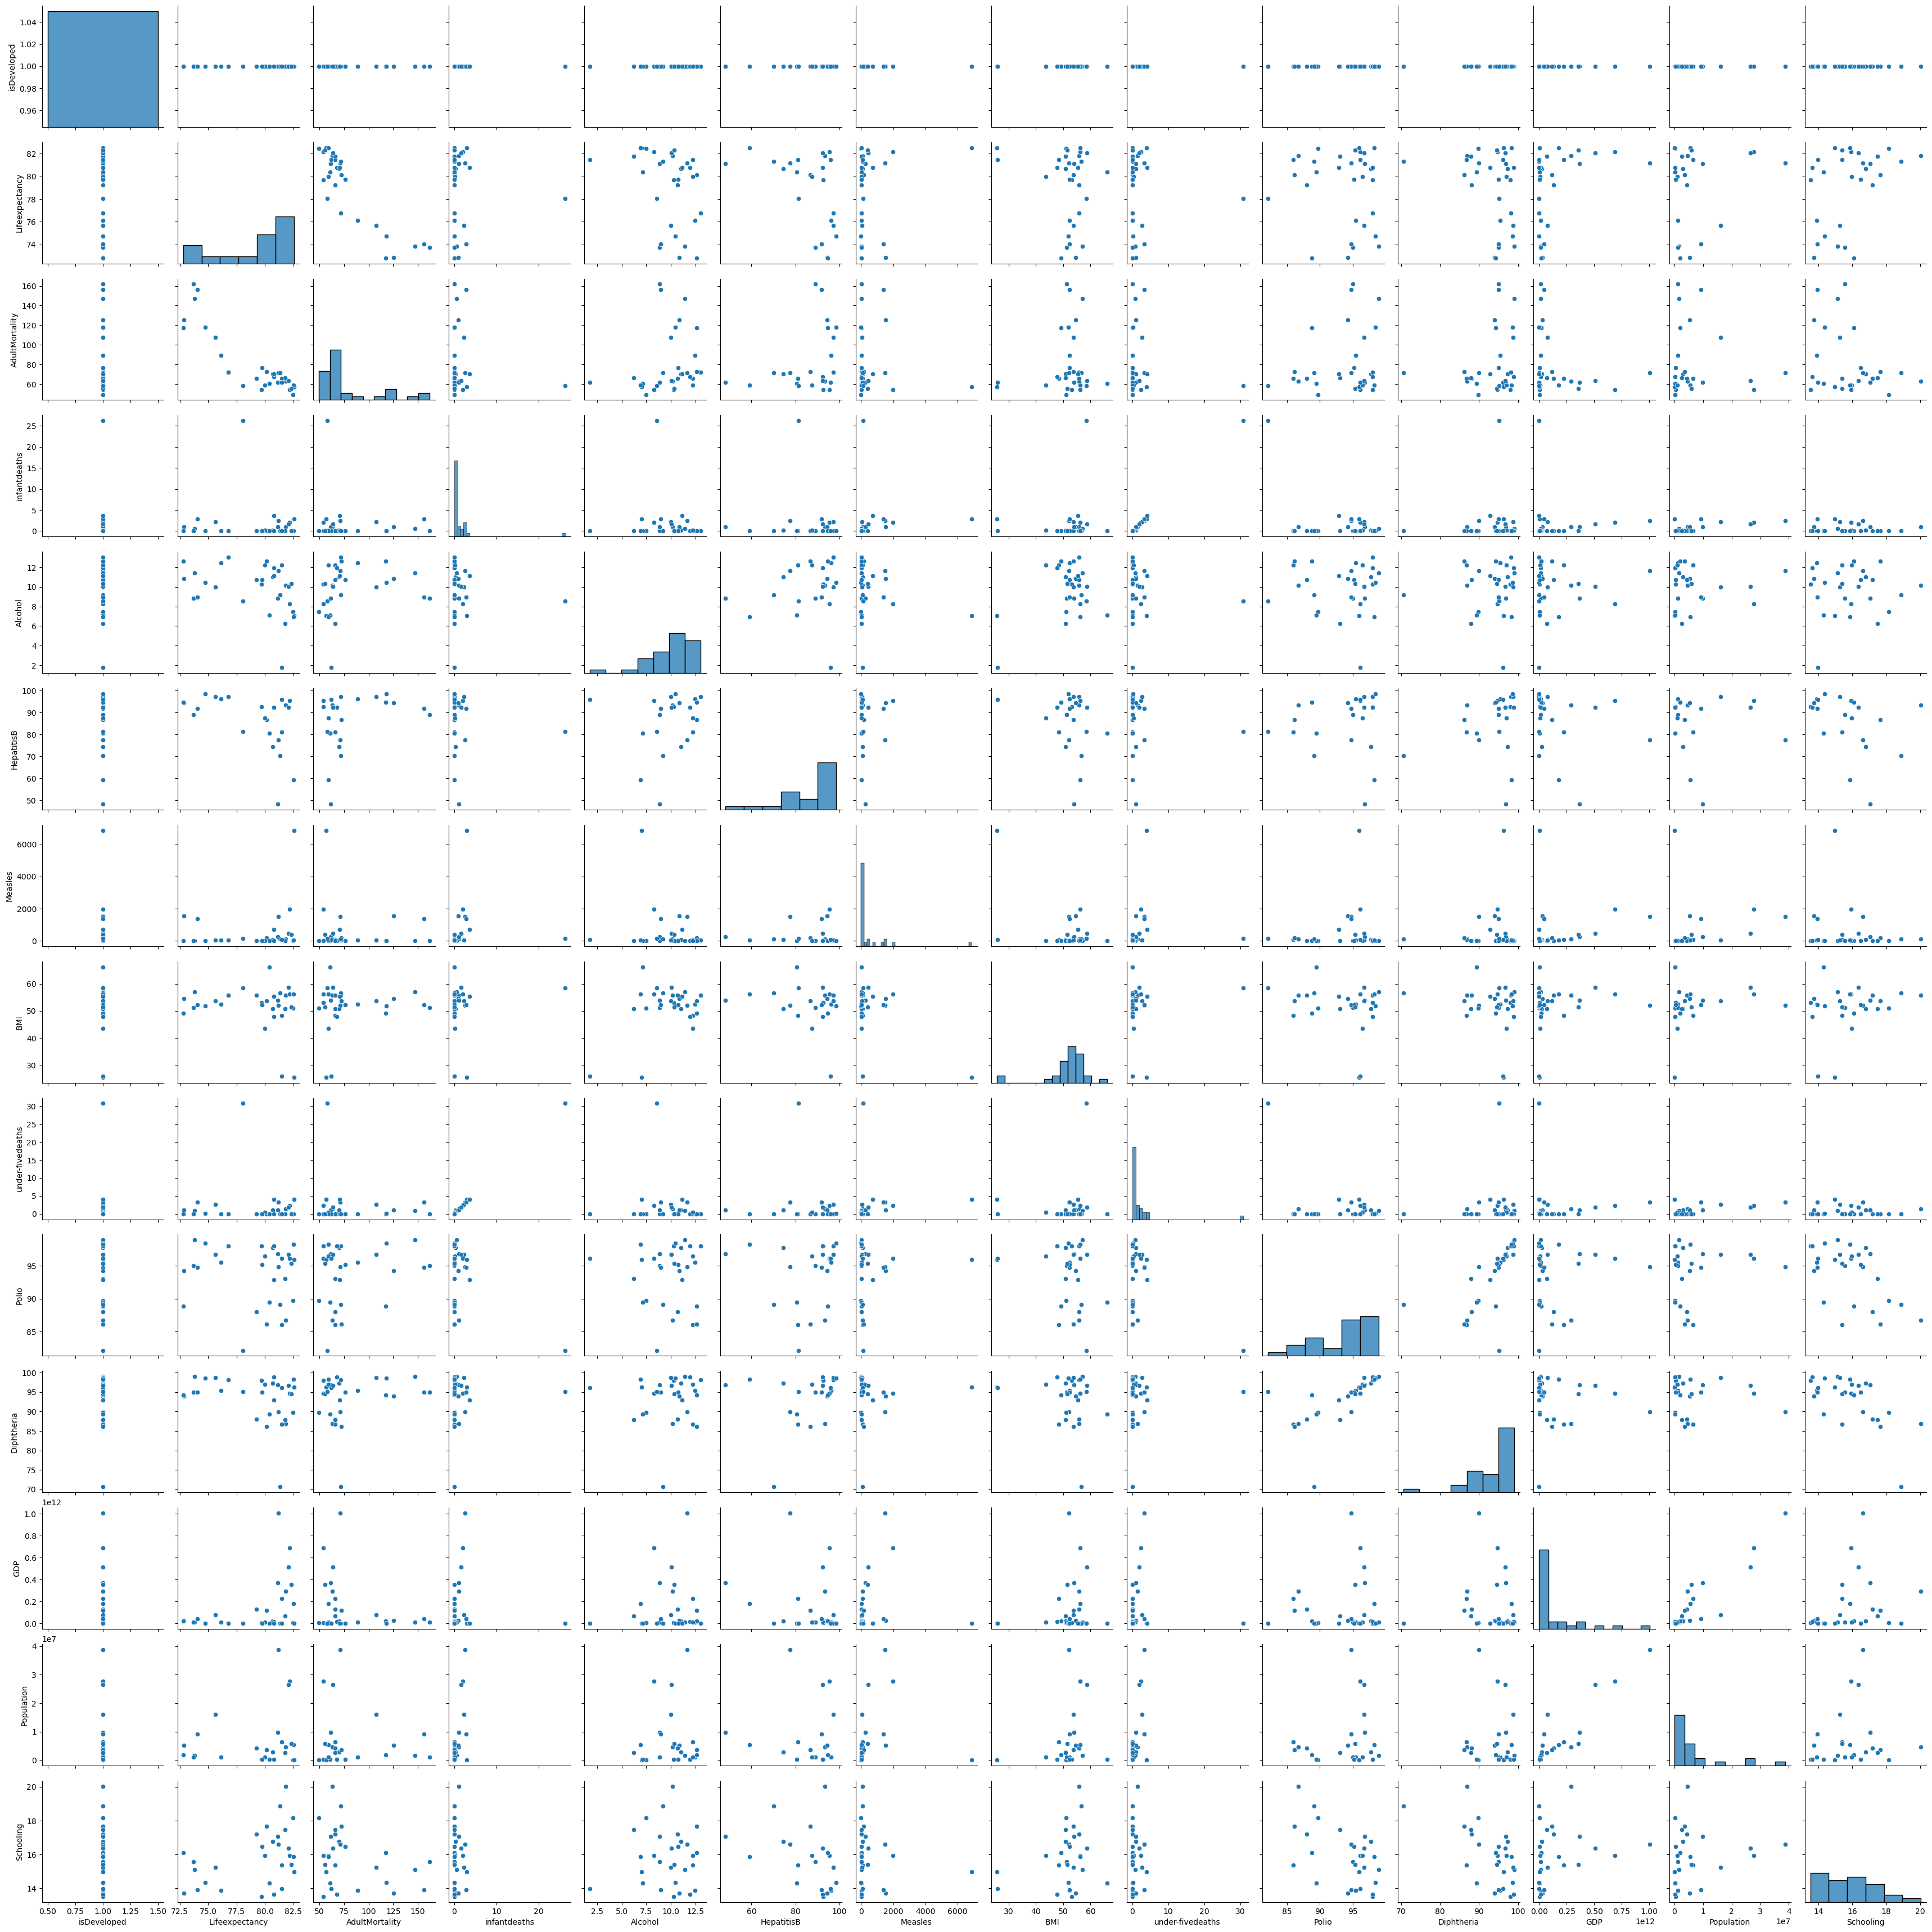

In [12]:
sns.pairplot(dfLE[dfLE['isDeveloped']==1].select_dtypes(include = 'number'))

<Axes: >

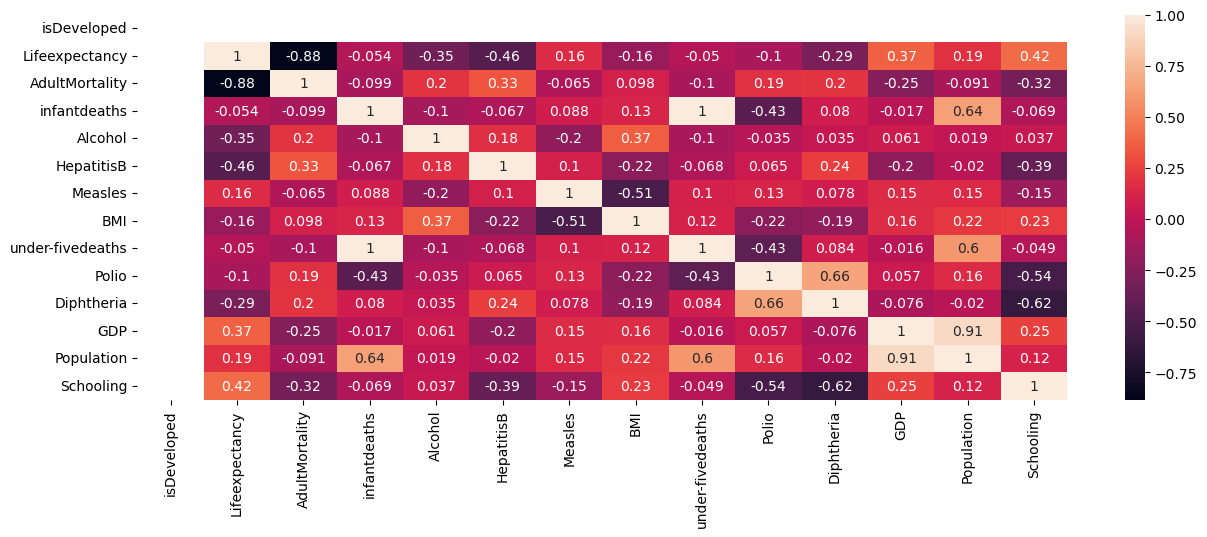

In [13]:
sns.heatmap(dfLE[dfLE['isDeveloped']==1].select_dtypes(include = 'number').corr(),annot = True)

under five death and infant death have perfect correlation in developed countries. This can be as a result of cofounding correlation because they are both indicators of infant mortality.

In [14]:
dfLE[dfLE['Population']==max(dfLE['Population'])]['Country']

76    India
Name: Country, dtype: object

In [15]:
dfLE.columns

Index(['Country', 'isDeveloped', 'Lifeexpectancy', 'AdultMortality',
       'infantdeaths', 'Alcohol', 'HepatitisB', 'Measles', 'BMI',
       'under-fivedeaths', 'Polio', 'Diphtheria', 'GDP', 'Population',
       'Schooling'],
      dtype='object')

In [16]:
dfLE[dfLE['under-fivedeaths']==max(dfLE['under-fivedeaths'])]['Country']

76    India
Name: Country, dtype: object

In [17]:
dfLE[dfLE['infantdeaths']==max(dfLE['infantdeaths'])]['Country']

76    India
Name: Country, dtype: object

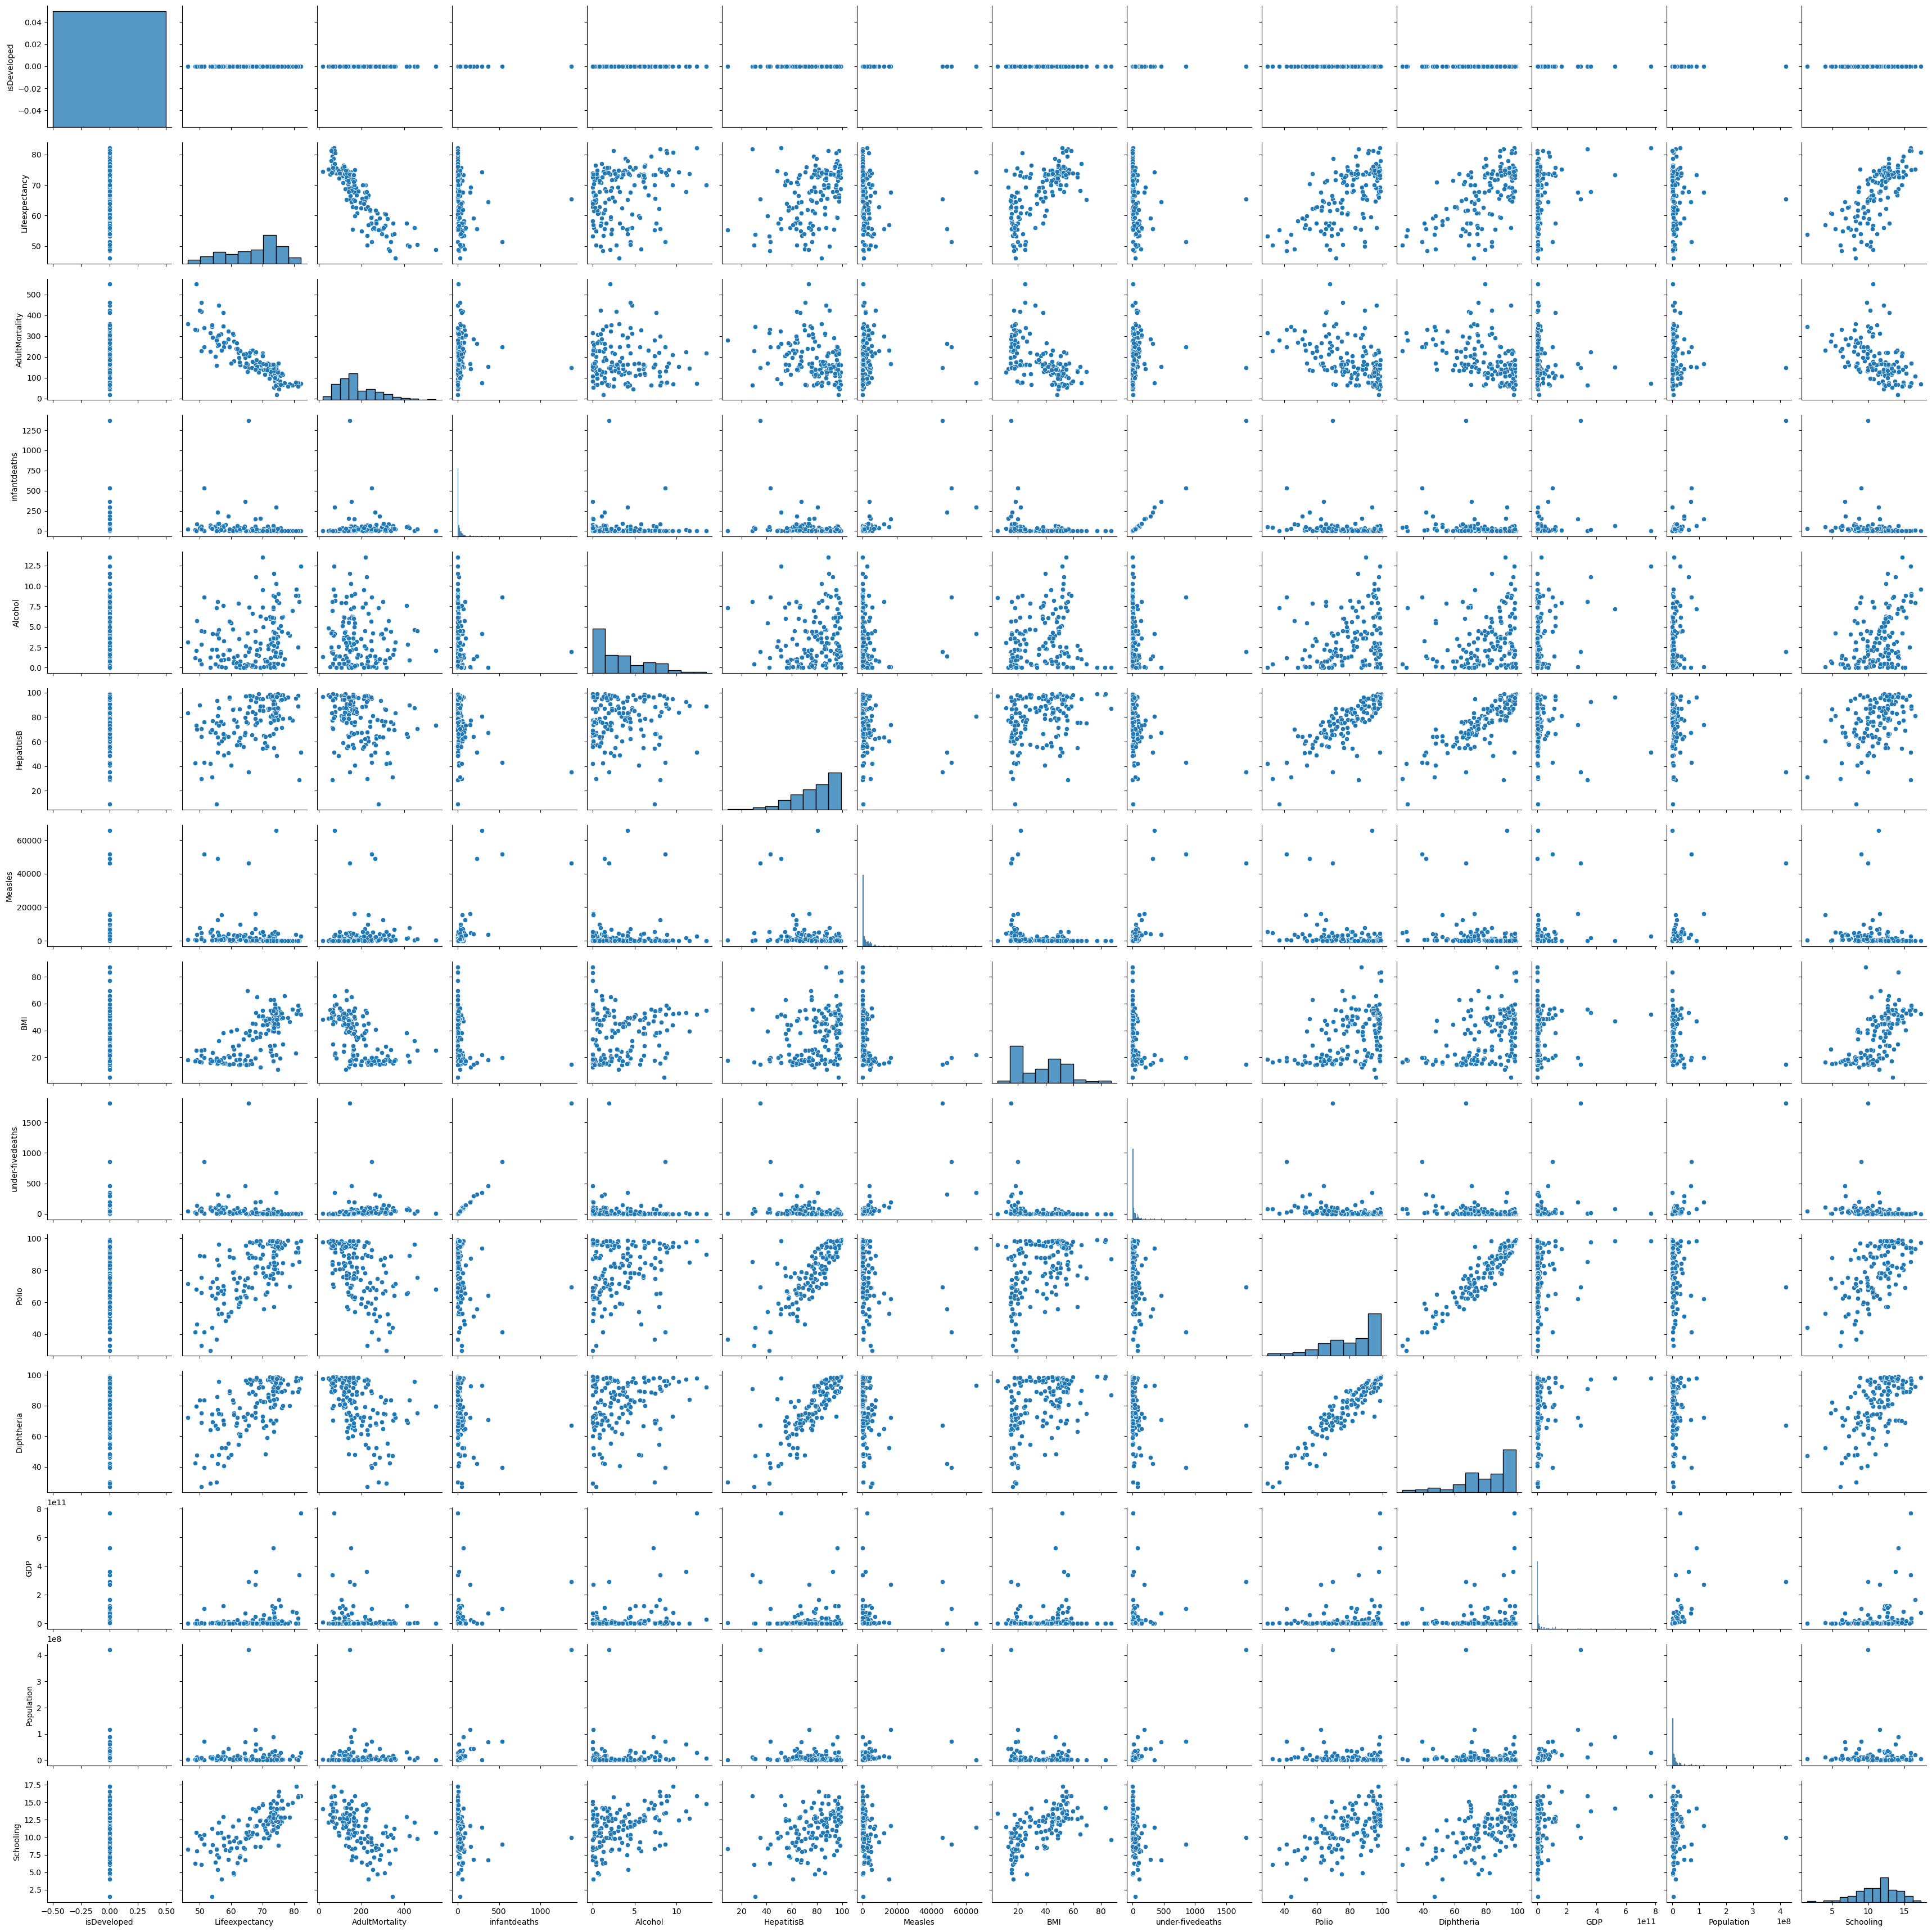

In [18]:
sns.pairplot(dfLE[dfLE['isDeveloped']==0].select_dtypes(include = 'number'))

<Axes: >

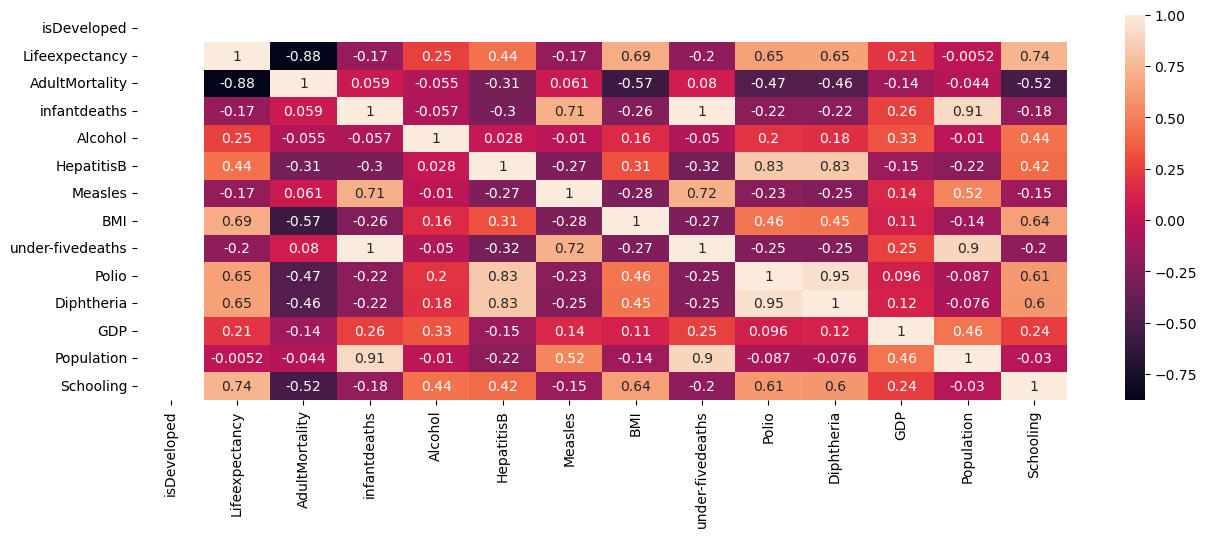

In [19]:
sns.heatmap(dfLE[dfLE['isDeveloped']==0].select_dtypes(include = 'number').corr(),annot = True)

Population, under five deaths and infant death have near perfect correlation in under developed countries. This can be as a result of cofounding correlation because the infants mortality directly determines the number of people living in a particular area.

### 4b. Remove outliers


In [20]:
### Under five deaths for developed countries
max_ud = dfLE.loc[dfLE['isDeveloped']==1,'under-fivedeaths'].max()
dfLE[dfLE['under-fivedeaths']==max_ud]['Country']

182    UnitedStatesofAmerica
Name: Country, dtype: object

In [21]:
### Under five deaths for under developed countries
max_ud = dfLE.loc[dfLE['isDeveloped']==0,'under-fivedeaths'].max()
dfLE[dfLE['under-fivedeaths']==max_ud]['Country']

76    India
Name: Country, dtype: object

In [22]:
### Infant deaths for developed countries
max_ud = dfLE.loc[dfLE['isDeveloped']==1,'infantdeaths'].max()
dfLE[dfLE['infantdeaths']==max_ud]['Country']

182    UnitedStatesofAmerica
Name: Country, dtype: object

In [23]:
### Infant deaths for under developed countries
max_ud = dfLE.loc[dfLE['isDeveloped']==0,'infantdeaths'].max()
dfLE[dfLE['infantdeaths']==max_ud]['Country']

76    India
Name: Country, dtype: object

In [24]:
### Population for under developed countries
max_ud = dfLE.loc[dfLE['isDeveloped']==0,'Population'].max()
dfLE[dfLE['Population']==max_ud]['Country']

76    India
Name: Country, dtype: object

In [25]:
dfLE = dfLE[~dfLE['Country'].isin(['UnitedStatesofAmerica','Indian'])]

### Part 5: Calculate correlations (25pts)

<ul>
<li>5 points are for identifying and calculating 3 strongest correlations with life expectancy for each of developed and not developed.
<li>10 points are for analyzing those correlations. Do they appear to be supported by reality? Do you have reason to beleive any are causal?
<li>10 points are for identifying 2 places where developing and developed countries have a substantially different relationship with respect to life expectancy, and theorizing why. What would be needed to confirm your thoughts?
</ul>

<b>Please put your written parts in markdown cells, with a little formatting to make them readable.

In [26]:
#Calculate correlations and analyze.

<Axes: >

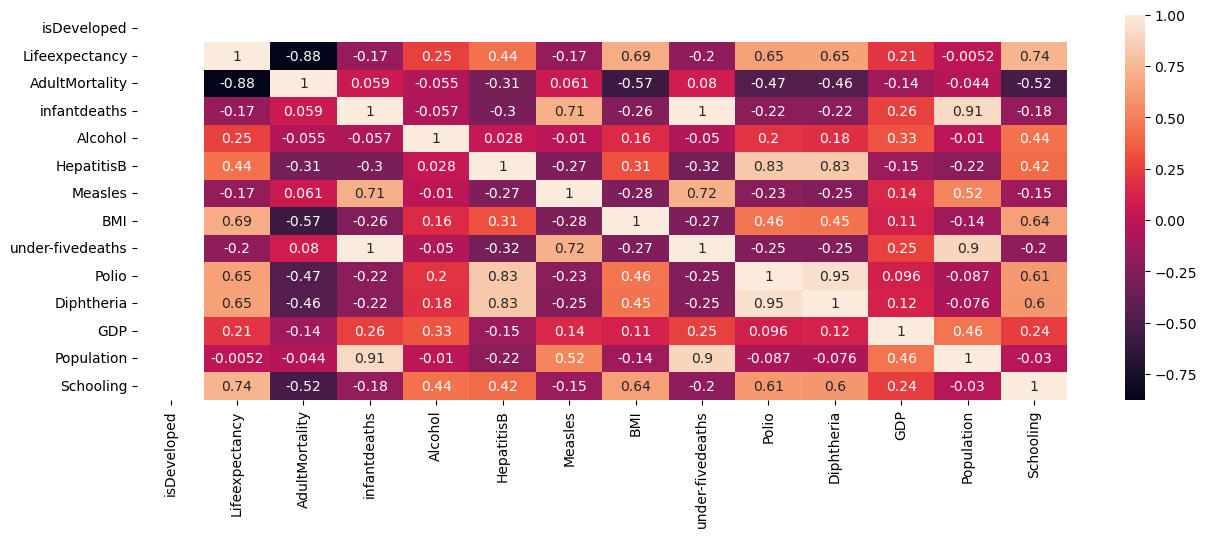

In [27]:
sns.heatmap(dfLE[dfLE['isDeveloped']==0].select_dtypes(include = 'number').corr(),annot = True)

Adult mortality, BMI, Polio and Diphtheria have the strongest correlation with life expentancy. BMI, Polio and Diphtheria are health indicators which directly affects life expentancy.

On the other hand, adult mortality which is also an indicator for health outcomes has a strong relationship with life expentancy but with an unexpected direction(negative). We expect it to have a positive relationship beacuse they are both indicators of poor health outcomes.

<Axes: >

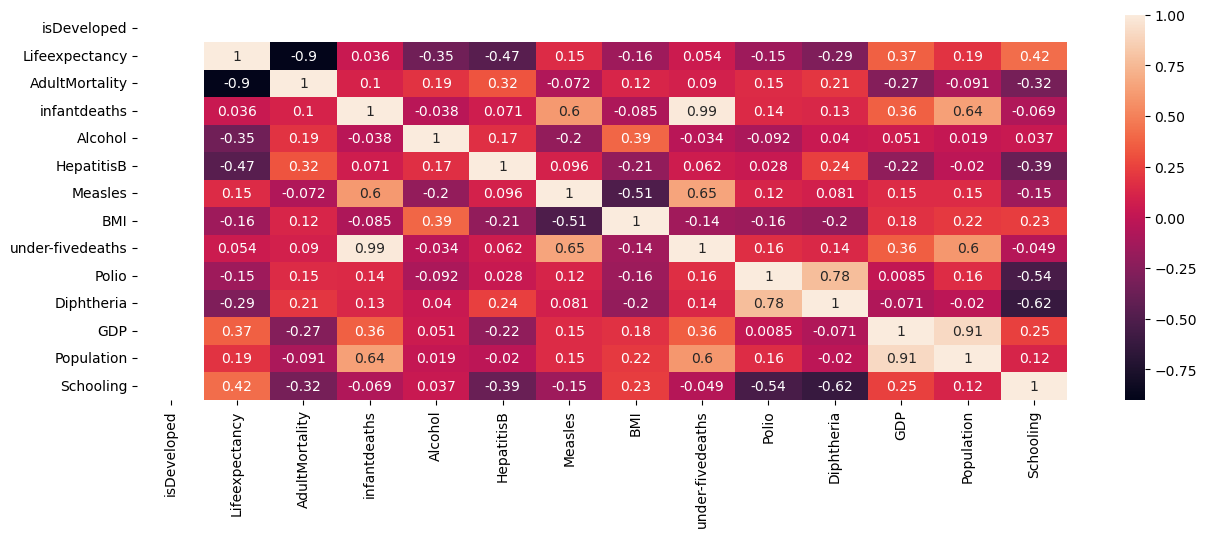

In [28]:
sns.heatmap(dfLE[dfLE['isDeveloped']==1].select_dtypes(include = 'number').corr(),annot = True)

Adult mortality which is also an indicator for health outcomes has a strong relationship with life expentancy but with an unexpected direction(negative). We expect it to have a positive relationship beacuse they are both indicators of poor health outcomes.


GDP and Hepatitis B have the second and third strongest correlation with life expentancy. However, the correlation is weak and inconsequential.

###. 5c.

From the heatmaps above, it can be seen that negative health outcomes like the disease related variables have weaker correlation with life expentancy in developed countries compared to underdeveloped countries. This is because, the more developed countries have better health care systems.